# Field Mapping 04 - Interactive Field Visualization

Visualize satellite, terrain, and soil property data for agricultural fields in Oregon's Willamette Valley.

**Instructions:**
1. Cell 2: Select a field ID and run the cell to set it
2. Cell 3: Run to visualize the selected field

## Overview

This notebook analyzes multi-source geospatial data for agricultural fields in Oregon's Willamette Valley. The analysis integrates three data categories:

1. **Satellite Indices** (derived from Landsat 8/9 imagery): NDVI, MSAVI, EVI, NDMI
2. **Terrain** (from USGS digital elevation models): Elevation, slope, aspect
3. **Soil Properties** (from USDA SSURGO): CEC, AWC, pH, sand %, silt %, clay %, organic matter %

The notebook provides:
- Visual comparisons of all data layers for a selected field
- Pixel value distributions within field boundaries
- Interactive correlation analysis between any two metrics
- Full correlation matrix showing pairwise Pearson coefficients
- P-value significance matrix showing statistical significance of correlations

**Data Sources:**
- Satellite imagery: USGS Landsat 8/9 Collection 2 Level-2
- Elevation/Terrain: USGS National Elevation Dataset (NED)
- Soil data: USDA NRCS Soil Survey Geographic Database (SSURGO)

## Key Findings (WV_AG_002)

Based on analysis of satellite imagery, terrain, and soil property data:

### 1. Flat, Low-Relief Terrain
- **Mean slope: 0.64°** — very flat terrain typical of Willamette Valley floodplain
- **Elevation range: 102-105m** — only ~3m variation across the entire field
- **Aspect: 160°** (southeast-facing)
- **Implication**: Highly suitable for mechanized agriculture with minimal erosion risk

### 2. Well-Drained, High-Capacity Soils
- **Soil type**: Malabon silty clay loam (100% coverage)
- **Drainage**: Well-drained
- **Organic Matter: 4.9%** — above regional average
- **pH: 6.10** — optimal for most crops
- **CEC: 24.5 meq/100g** — high nutrient-holding capacity
- **Texture**: 30% clay / 50% silt / 20% sand

### 3. Strong Elevation-Driven Environmental Gradients
- **NDVI vs Elevation**: r = -0.32 (p < 0.001) — lower elevations support denser vegetation
- **pH vs Organic Matter**: r = +0.46 (p < 0.001) — decomposition creates more acidic conditions
- **Elevation vs Clay**: r = -0.37 (p < 0.001) — clay particles settle in lower-lying areas
- **Implication**: Micro-topography significantly influences vegetation patterns and soil properties


In [97]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd

DATA_DIR = '/workspaces/ag-skills-demo/data'

FIELDS_GEOJSON = os.path.join(DATA_DIR, 'fields_oregon_willamette_ag_2025.geojson')
SATELLITE_DIR = os.path.join(DATA_DIR, 'satellite')
TERRAIN_DIR = os.path.join(DATA_DIR, 'terrain_resampled')
SOIL_DIR = os.path.join(DATA_DIR, 'soil_properties_resampled')

fields_gdf = gpd.read_file(FIELDS_GEOJSON)
raster_crs = 'EPSG:4326'
fields_gdf_4326 = fields_gdf.to_crs(raster_crs)
field_ids = sorted(fields_gdf['field_id'].tolist())
print(f"Loaded {len(field_ids)} fields: {field_ids[0]} to {field_ids[-1]}")
print(f"Field polygons transformed to {raster_crs} to match raster data")

Loaded 50 fields: WV_AG_001 to WV_AG_050
Field polygons transformed to EPSG:4326 to match raster data


## Select Field

Change the `FIELD_ID` value below and run this cell to select a field.

In [98]:
# Select the field to visualize
FIELD_ID = 'WV_AG_002' #040, 046, 036, 034, 029, 027, 026, 019, 016, 014,  002
print(f"Selected field: {FIELD_ID}")

Selected field: WV_AG_002


## Visualize Field

Run this cell to visualize the selected field. Re-run after changing the field in the cell above.

Visualizing WV_AG_002


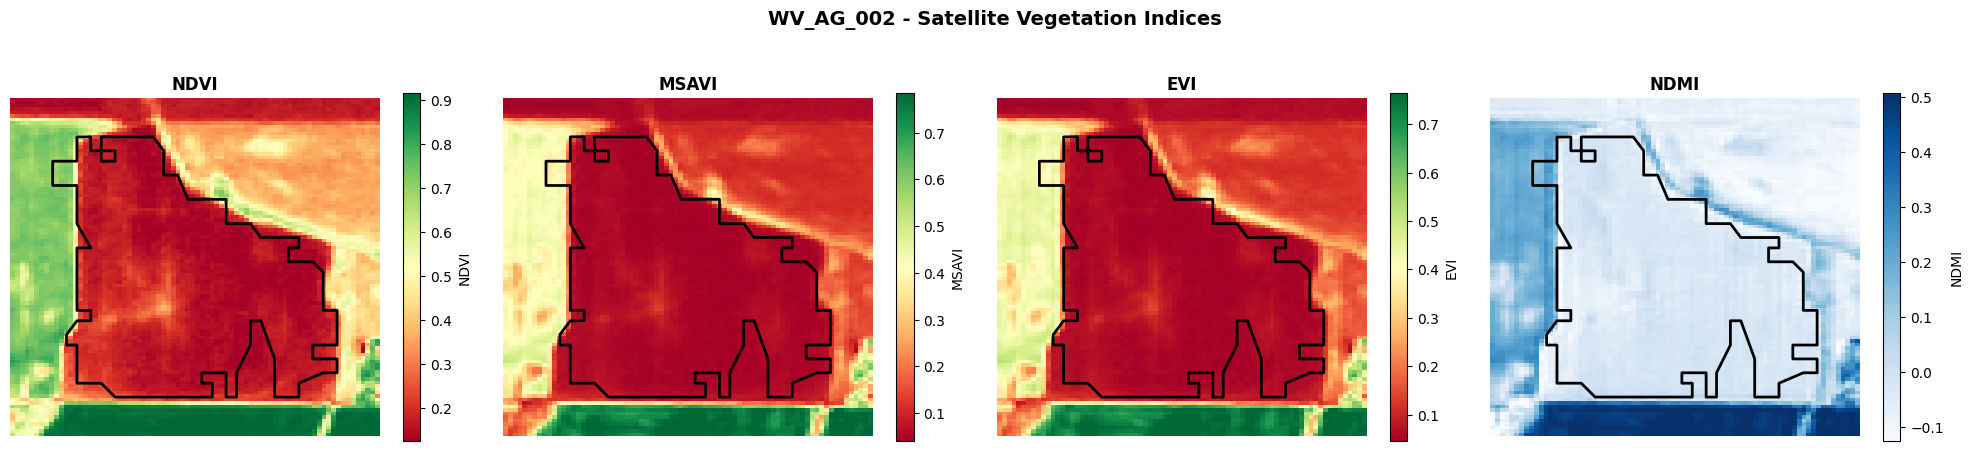

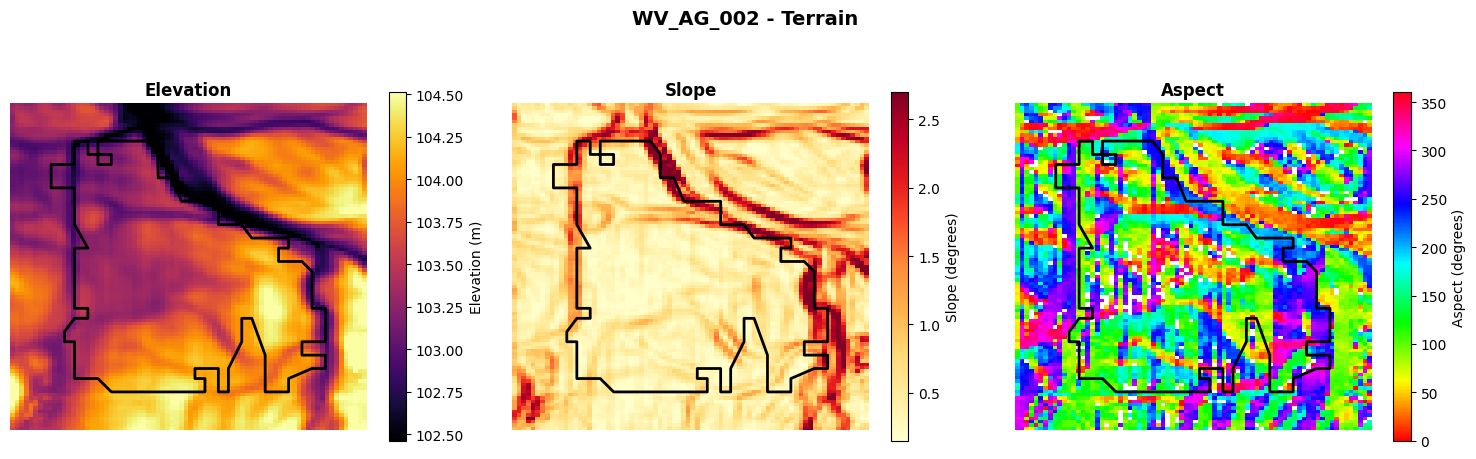

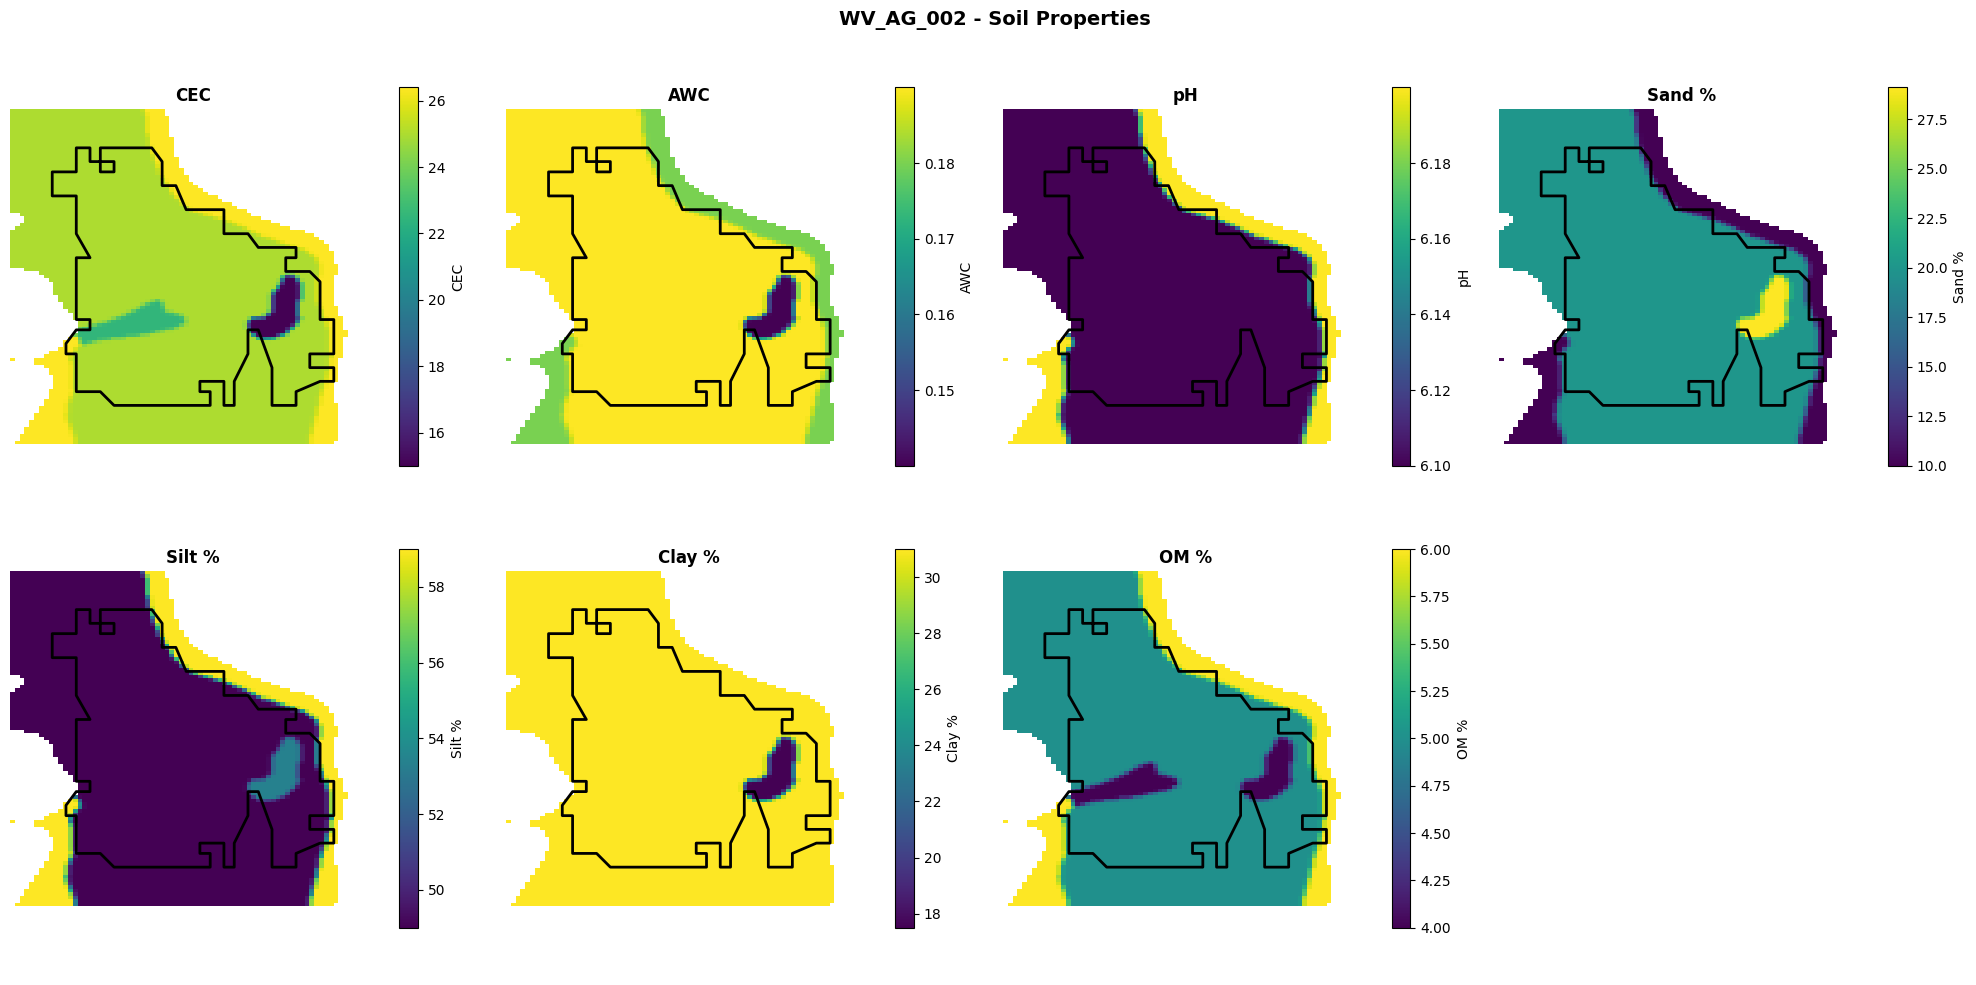

In [99]:
# Visualize the selected field
plt.close('all')

def get_field_polygon(field_id):
    """Extract polygon geometry for a field, in raster CRS (EPSG:4326)."""
    return fields_gdf_4326[fields_gdf_4326['field_id'] == field_id].geometry.iloc[0]

def load_raster(filepath):
    """Load a GeoTIFF and return data, transform, and nodata value."""
    with rasterio.open(filepath) as src:
        data = src.read(1)
        transform = src.transform
        nodata = src.nodata
    return data, transform, nodata

def calculate_percentile_bounds(data, nodata=None, p_low=2, p_high=98):
    """Calculate 2nd and 98th percentile bounds for color scaling."""
    valid = data.copy()
    if nodata is not None and not np.isnan(nodata):
        valid = data[data != nodata]
    valid = valid[~np.isnan(valid)]
    return np.percentile(valid, p_low), np.percentile(valid, p_high)

def calculate_exact_bounds(data, nodata=None):
    """Calculate exact min/max bounds."""
    valid = data.copy()
    if nodata is not None and not np.isnan(nodata):
        valid = data[data != nodata]
    valid = valid[~np.isnan(valid)]
    return np.min(valid), np.max(valid)

def plot_with_polygon(ax, data, transform, polygon, cmap, vmin, vmax, title, nodata=None):
    """Plot raster with field polygon overlay using extent-based coordinate mapping."""
    masked_data = np.ma.masked_invalid(data) if nodata is None or np.isnan(nodata) else np.ma.masked_where(data == nodata, data)
    
    height, width = data.shape
    xmin = transform.c
    xmax = transform.c + transform.a * width
    ymax = transform.f
    ymin = transform.f + transform.e * height
    extent = [xmin, xmax, ymin, ymax]
    
    im = ax.imshow(masked_data, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent, origin='upper')
    
    if hasattr(polygon, 'exterior'):
        x, y = polygon.exterior.coords.xy
        ax.plot(x, y, 'k-', linewidth=2)
    
    if hasattr(polygon, 'geoms'):
        for geom in polygon.geoms:
            if hasattr(geom, 'exterior'):
                x, y = geom.exterior.coords.xy
                ax.plot(x, y, 'k-', linewidth=2)
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_axis_off()
    return im

def visualize_field(field_id):
    """Visualize all satellite, terrain, and soil data for a field."""
    polygon = get_field_polygon(field_id)
    
    print(f"Visualizing {field_id}")
    
    # === GROUP 1: Satellite Indices ===
    satellite_metrics = ['ndvi', 'msavi', 'evi', 'ndmi']
    cmap_sat = {'ndvi': 'RdYlGn', 'msavi': 'RdYlGn', 'evi': 'RdYlGn', 'ndmi': 'Blues'}
    
    fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
    fig1.suptitle(f'{field_id} - Satellite Vegetation Indices', fontsize=14, fontweight='bold')
    
    for idx, metric in enumerate(satellite_metrics):
        filepath = os.path.join(SATELLITE_DIR, f'{field_id}_{metric}.tif')
        if os.path.exists(filepath):
            data, transform, nodata = load_raster(filepath)
            vmin, vmax = calculate_percentile_bounds(data, nodata)
            im = plot_with_polygon(axes1[idx], data, transform, polygon, cmap_sat[metric], 
                                   vmin, vmax, metric.upper(), nodata)
            cbar = plt.colorbar(im, ax=axes1[idx], shrink=0.8)
            cbar.set_label(f'{metric.upper()}')
        else:
            axes1[idx].text(0.5, 0.5, f'{metric.upper()}\nNot Found', ha='center', va='center')
            axes1[idx].set_title(metric.upper())
            axes1[idx].set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    # === GROUP 2: Terrain ===
    terrain_metrics = ['elevation', 'slope', 'aspect']
    cmap_terrain = {'elevation': 'inferno', 'slope': 'YlOrRd', 'aspect': 'hsv'}
    
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    fig2.suptitle(f'{field_id} - Terrain', fontsize=14, fontweight='bold')
    
    for idx, metric in enumerate(terrain_metrics):
        filepath = os.path.join(TERRAIN_DIR, f'{field_id}_{metric}.tif')
        if os.path.exists(filepath):
            data, transform, nodata = load_raster(filepath)
            if metric == 'aspect':
                vmin, vmax = 0, 360
            else:
                vmin, vmax = calculate_percentile_bounds(data, nodata)
            
            im = plot_with_polygon(axes2[idx], data, transform, polygon, cmap_terrain[metric], 
                                   vmin, vmax, metric.capitalize(), nodata)
            cbar = plt.colorbar(im, ax=axes2[idx], shrink=0.8)
            
            if metric == 'elevation':
                cbar.set_label('Elevation (m)')
            elif metric == 'slope':
                cbar.set_label('Slope (degrees)')
            else:
                cbar.set_label('Aspect (degrees)')
        else:
            axes2[idx].text(0.5, 0.5, f'{metric.capitalize()}\nNot Found', ha='center', va='center')
            axes2[idx].set_title(metric.capitalize())
            axes2[idx].set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    # === GROUP 3: Soil Properties ===
    soil_metrics = ['cec', 'awc', 'ph', 'sand_pct', 'silt_pct', 'clay_pct', 'om_pct']
    soil_names = ['CEC', 'AWC', 'pH', 'Sand %', 'Silt %', 'Clay %', 'OM %']
    cmap_soil = 'viridis'
    
    n_cols = 4
    n_rows = (len(soil_metrics) + n_cols - 1) // n_cols
    fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    fig3.suptitle(f'{field_id} - Soil Properties', fontsize=14, fontweight='bold')
    
    if n_rows == 1:
        axes3 = axes3.reshape(1, -1)
    
    axes3_flat = axes3.flatten()
    
    for idx, (metric, name) in enumerate(zip(soil_metrics, soil_names)):
        filepath = os.path.join(SOIL_DIR, f'{field_id}_soil_{metric}.tif')
        if os.path.exists(filepath):
            data, transform, nodata = load_raster(filepath)
            vmin, vmax = calculate_exact_bounds(data, nodata)
            im = plot_with_polygon(axes3_flat[idx], data, transform, polygon, cmap_soil, 
                                   vmin, vmax, name, nodata)
            cbar = plt.colorbar(im, ax=axes3_flat[idx], shrink=0.8)
            cbar.set_label(name)
        else:
            axes3_flat[idx].text(0.5, 0.5, f'{name}\nNot Found', ha='center', va='center')
            axes3_flat[idx].set_title(name)
            axes3_flat[idx].set_axis_off()
    
    for idx in range(len(soil_metrics), len(axes3_flat)):
        axes3_flat[idx].set_axis_off()
    
    plt.tight_layout()
    plt.show()

# Run visualization for selected field
visualize_field(FIELD_ID)

## Pixel Value Histograms

Histogram distributions of pixel values within the field polygon.

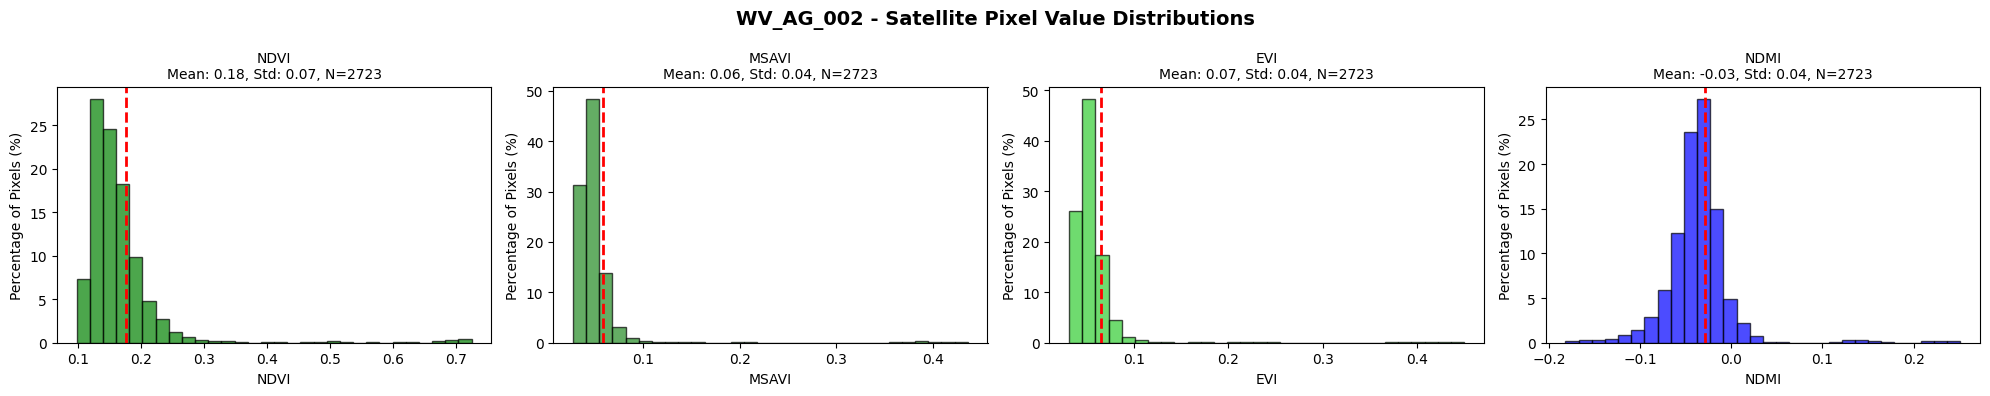

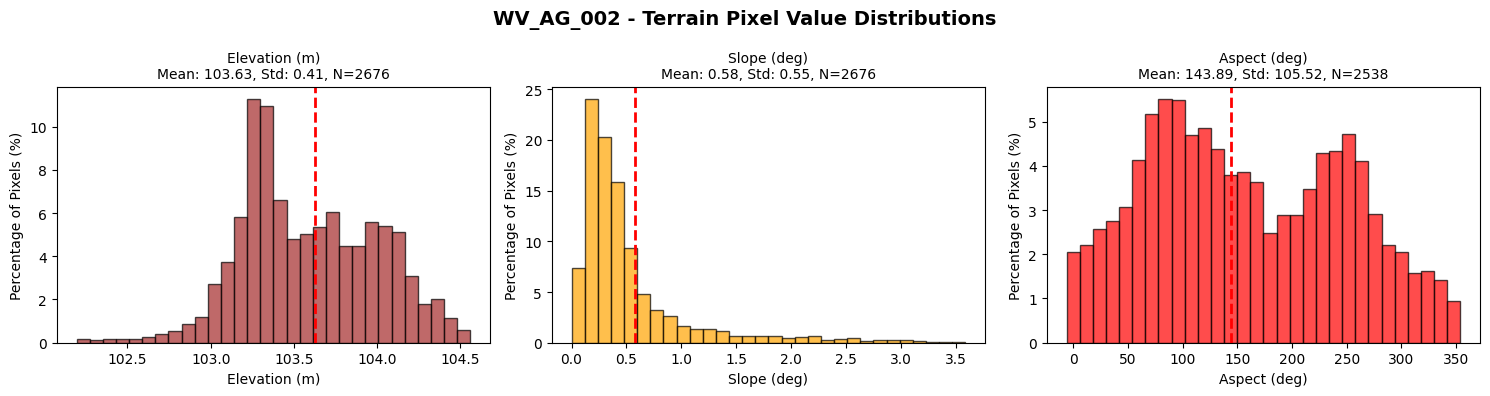

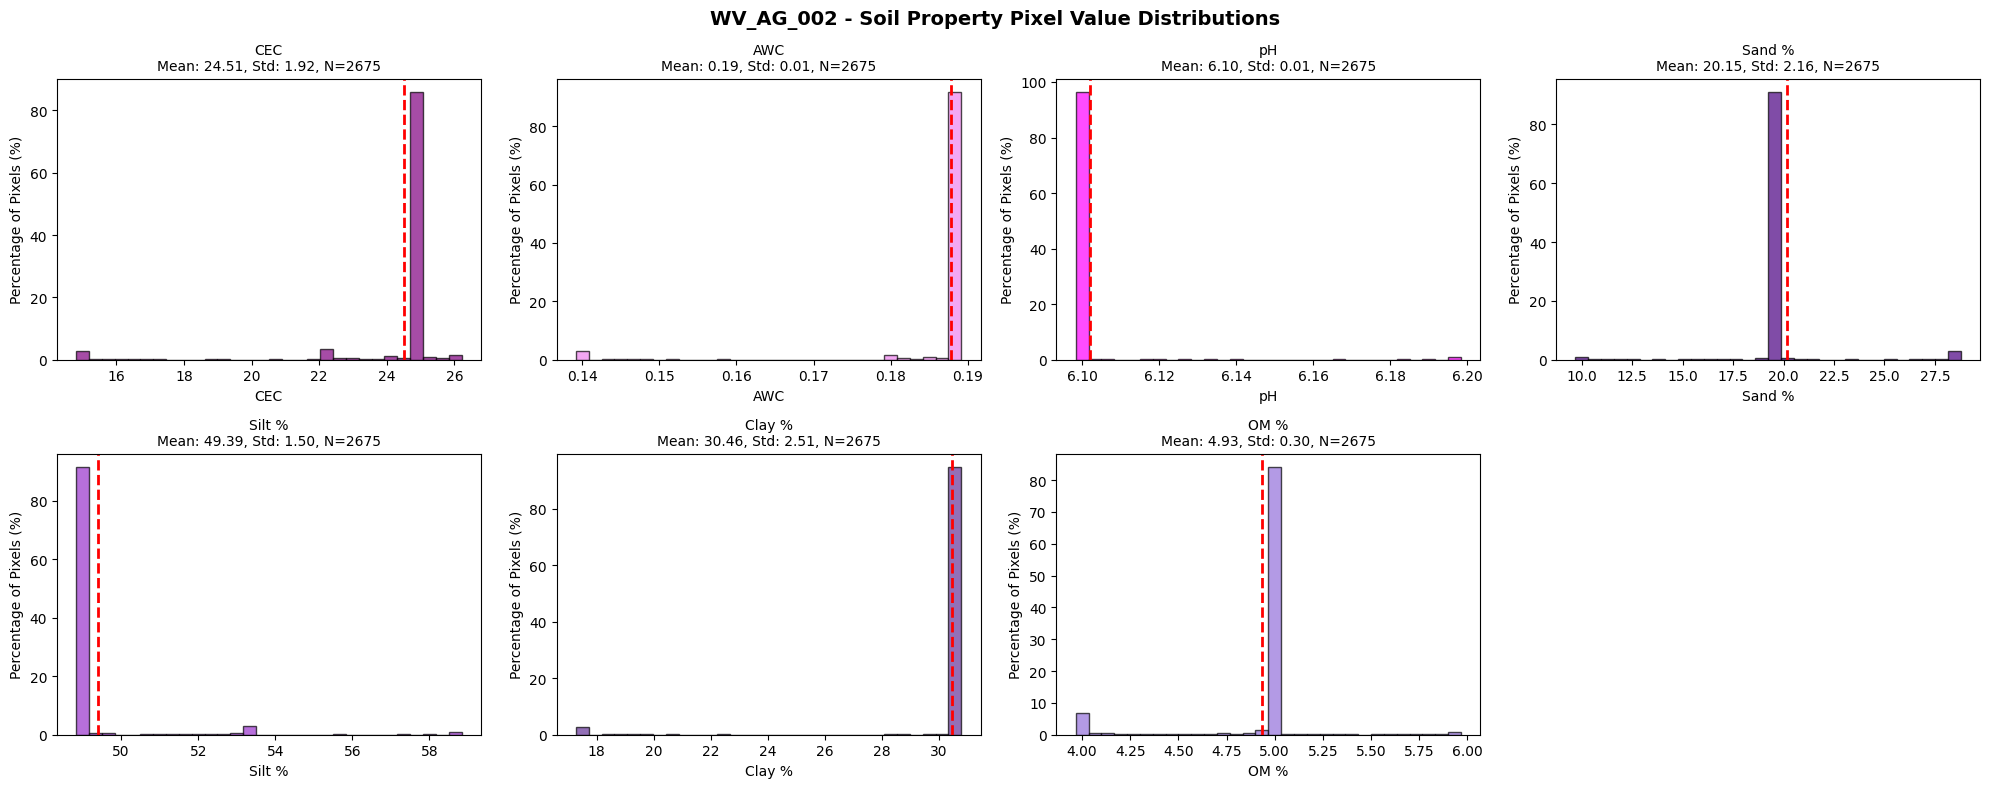

In [100]:
# Pixel Value Histograms
from rasterio import mask

def get_pixel_values(raster_path, polygon):
    """Extract valid pixel values within a polygon using rasterio.mask."""
    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask.mask(src, [polygon], crop=True)
        data = out_image[0]
        
        nodata = src.nodata
        values = data.flatten()
        
        if nodata is not None and not np.isnan(nodata):
            values = values[values != nodata]
        values = values[~np.isnan(values)]
        
        return values

def circular_mean(values):
    """Calculate circular mean for aspect values (0-360 degrees)."""
    rad = np.deg2rad(values)
    sin_mean = np.mean(np.sin(rad))
    cos_mean = np.mean(np.cos(rad))
    mean_rad = np.arctan2(sin_mean, cos_mean)
    return np.rad2deg(mean_rad) % 360

def circular_std(values):
    """Calculate circular standard deviation for aspect values."""
    rad = np.deg2rad(values)
    sin_mean = np.mean(np.sin(rad))
    cos_mean = np.mean(np.cos(rad))
    R = np.sqrt(sin_mean**2 + cos_mean**2)
    return np.degrees(np.sqrt(-2 * np.log(R)))

def plot_histogram(ax, values, metric_name, color='blue', is_circular=False):
    """Plot histogram with mean line and statistics in title."""
    if len(values) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
        return
    
    if is_circular:
        mean_val = circular_mean(values)
        std_val = circular_std(values)
    else:
        mean_val = np.mean(values)
        std_val = np.std(values)
    
    n_pixels = len(values)
    
    counts, bins = np.histogram(values, bins=30)
    percentages = counts / len(values) * 100
    ax.bar(bins[:-1], percentages, width=np.diff(bins), color=color, alpha=0.7, edgecolor='black')
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f'{metric_name}\nMean: {mean_val:.2f}, Std: {std_val:.2f}, N={n_pixels}', fontsize=10)
    ax.set_xlabel(metric_name)
    ax.set_ylabel('Percentage of Pixels (%)')

polygon = get_field_polygon(FIELD_ID)

# === GROUP 1: Satellite Indices ===
satellite_metrics = ['ndvi', 'msavi', 'evi', 'ndmi']
satellite_names = ['NDVI', 'MSAVI', 'EVI', 'NDMI']
satellite_colors = ['green', 'forestgreen', 'limegreen', 'blue']

fig1, axes1 = plt.subplots(1, 4, figsize=(20, 4))
fig1.suptitle(f'{FIELD_ID} - Satellite Pixel Value Distributions', fontsize=14, fontweight='bold')

for idx, (metric, name, color) in enumerate(zip(satellite_metrics, satellite_names, satellite_colors)):
    filepath = os.path.join(SATELLITE_DIR, f'{FIELD_ID}_{metric}.tif')
    if os.path.exists(filepath):
        values = get_pixel_values(filepath, polygon)
        plot_histogram(axes1[idx], values, name, color=color)
    else:
        axes1[idx].text(0.5, 0.5, 'Not Found', ha='center', va='center', transform=axes1[idx].transAxes)
        axes1[idx].set_title(name)

plt.tight_layout()
plt.show()

# === GROUP 2: Terrain ===
terrain_metrics = ['elevation', 'slope', 'aspect']
terrain_names = ['Elevation (m)', 'Slope (deg)', 'Aspect (deg)']
terrain_colors = ['brown', 'orange', 'red']
terrain_circular = [False, False, True]

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle(f'{FIELD_ID} - Terrain Pixel Value Distributions', fontsize=14, fontweight='bold')

for idx, (metric, name, color, is_circ) in enumerate(zip(terrain_metrics, terrain_names, terrain_colors, terrain_circular)):
    filepath = os.path.join(TERRAIN_DIR, f'{FIELD_ID}_{metric}.tif')
    if os.path.exists(filepath):
        values = get_pixel_values(filepath, polygon)
        plot_histogram(axes2[idx], values, name, color=color, is_circular=is_circ)
    else:
        axes2[idx].text(0.5, 0.5, 'Not Found', ha='center', va='center', transform=axes2[idx].transAxes)
        axes2[idx].set_title(name)

plt.tight_layout()
plt.show()

# === GROUP 3: Soil Properties ===
soil_metrics = ['cec', 'awc', 'ph', 'sand_pct', 'silt_pct', 'clay_pct', 'om_pct']
soil_names = ['CEC', 'AWC', 'pH', 'Sand %', 'Silt %', 'Clay %', 'OM %']
soil_colors = ['purple', 'violet', 'magenta', 'indigo', 'darkorchid', 'rebeccapurple', 'mediumpurple']

n_cols = 4
n_rows = (len(soil_metrics) + n_cols - 1) // n_cols
fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
fig3.suptitle(f'{FIELD_ID} - Soil Property Pixel Value Distributions', fontsize=14, fontweight='bold')

if n_rows == 1:
    axes3 = axes3.reshape(1, -1)

axes3_flat = axes3.flatten()

for idx, (metric, name, color) in enumerate(zip(soil_metrics, soil_names, soil_colors)):
    filepath = os.path.join(SOIL_DIR, f'{FIELD_ID}_soil_{metric}.tif')
    if os.path.exists(filepath):
        values = get_pixel_values(filepath, polygon)
        plot_histogram(axes3_flat[idx], values, name, color=color)
    else:
        axes3_flat[idx].text(0.5, 0.5, 'Not Found', ha='center', va='center', transform=axes3_flat[idx].transAxes)
        axes3_flat[idx].set_title(name)

for idx in range(len(soil_metrics), len(axes3_flat)):
    axes3_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

## Pixel-by-Pixel Correlation Plot

In [ ]:
# Pixel-by-Pixel Correlation Plot
from ipywidgets import interact_manual, Dropdown

from scipy import stats
from IPython.display import clear_output

# Define metrics organized by category
satellite_metrics = ['ndvi', 'msavi', 'evi', 'ndmi']
terrain_metrics = ['elevation', 'slope', 'aspect']
soil_metrics = ['cec', 'awc', 'ph', 'sand_pct', 'silt_pct', 'clay_pct', 'om_pct']

satellite_names = ['NDVI', 'MSAVI', 'EVI', 'NDMI']
terrain_names = ['Elevation', 'Slope', 'Aspect']
soil_names = ['CEC', 'AWC', 'pH', 'Sand %', 'Silt %', 'Clay %', 'OM %']

# Create organized dropdown options
x_options = {}
y_options = {}

for name in satellite_names:
    x_options[f'Satellite - {name}'] = ('satellite', name.lower())
    y_options[f'Satellite - {name}'] = ('satellite', name.lower())

for name in terrain_names:
    x_options[f'Terrain - {name}'] = ('terrain', name.lower())
    y_options[f'Terrain - {name}'] = ('terrain', name.lower())

for metric, name in zip(soil_metrics, soil_names):
    x_options[f'Soil - {name}'] = ('soil', metric)
    y_options[f'Soil - {name}'] = ('soil', metric)

def load_aligned_pixels(field_id, data_type, metric):
    """Load raster and extract valid pixel values within the polygon boundary."""
    from rasterio import mask
    
    polygon = get_field_polygon(field_id)
    
    if data_type == 'satellite':
        filepath = os.path.join(SATELLITE_DIR, f'{field_id}_{metric}.tif')
    elif data_type == 'terrain':
        filepath = os.path.join(TERRAIN_DIR, f'{field_id}_{metric}.tif')
    else:  # soil
        filepath = os.path.join(SOIL_DIR, f'{field_id}_soil_{metric}.tif')
    
    with rasterio.open(filepath) as src:
        out_image, out_transform = mask.mask(src, [polygon], crop=True)
        data = out_image[0]
        nodata = src.nodata
    
    # Flatten and filter nodata
    values = data.flatten()
    if nodata is not None and not np.isnan(nodata):
        values = values[values != nodata]
    values = values[~np.isnan(values)]
    
    return values

def plot_correlation(ax, x_values, y_values, x_name, y_name):
    """Plot scatter with fit line and correlation statistics."""
    if len(x_values) == 0 or len(y_values) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
        return
    
    # Align to common length
    min_len = min(len(x_values), len(y_values))
    x = x_values[:min_len]
    y = y_values[:min_len]
    
    # Calculate regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.5, s=10, c='blue')
    
    # Fit line
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, 'r-', linewidth=2, label='Fit Line')
    
    # Determine significance stars
    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    
    ax.set_title(f'{x_name} vs {y_name}\nr = {r_value:.3f}, p = {p_value:.2e} {sig}', fontsize=11)
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.legend()
    ax.grid(True, alpha=0.3)

def update_plot(x_choice, y_choice):
    """Update correlation plot based on dropdown selections."""
    from IPython.display import clear_output
    clear_output(wait=True)
    plt.close('all')
    
    x_type, x_metric = x_options[x_choice]
    y_type, y_metric = y_options[y_choice]
    
    # Load pixel values (now uses polygon mask)
    x_values = load_aligned_pixels(FIELD_ID, x_type, x_metric)
    y_values = load_aligned_pixels(FIELD_ID, y_type, y_metric)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_correlation(ax, x_values, y_values, x_choice, y_choice)
    plt.tight_layout()
    plt.show()

# Create dropdowns
x_dropdown = Dropdown(
    options=list(x_options.keys()),
    description='X Axis:',
    value='Satellite - NDVI'
)

y_dropdown = Dropdown(
    options=list(y_options.keys()),
    description='Y Axis:',
    value='Soil - CEC'
)

# Create button and output widget
from ipywidgets import Button, Output
output = Output()
button = Button(description='Generate Plot')

def on_button_click(b):
    with output:
        clear_output(wait=True)
        plt.close('all')
        x_choice = x_dropdown.value
        y_choice = y_dropdown.value
        x_type, x_metric = x_options[x_choice]
        y_type, y_metric = y_options[y_choice]
        x_values = load_aligned_pixels(FIELD_ID, x_type, x_metric)
        y_values = load_aligned_pixels(FIELD_ID, y_type, y_metric)
        fig, ax = plt.subplots(figsize=(8, 6))
        plot_correlation(ax, x_values, y_values, x_choice, y_choice)
        plt.tight_layout()
        plt.show()

button.on_click(on_button_click)
display(x_dropdown, y_dropdown, button, output)

Dropdown(description='X Axis:', options=('Satellite - NDVI', 'Satellite - MSAVI', 'Satellite - EVI', 'Satellit…

Dropdown(description='Y Axis:', index=7, options=('Satellite - NDVI', 'Satellite - MSAVI', 'Satellite - EVI', …

Button(description='Generate Plot', style=ButtonStyle())

Output()

## Correlation Matrix

Loading metrics for WV_AG_002...
  NDVI: 2723 pixels
  MSAVI: 2723 pixels
  EVI: 2723 pixels
  NDMI: 2723 pixels
  Elevation: 2676 pixels
  Slope: 2676 pixels
  Aspect: 2538 pixels
  CEC: 2675 pixels
  AWC: 2675 pixels
  pH: 2675 pixels
  Sand %: 2675 pixels
  Silt %: 2675 pixels
  Clay %: 2675 pixels
  OM %: 2675 pixels

Computing correlation matrix...


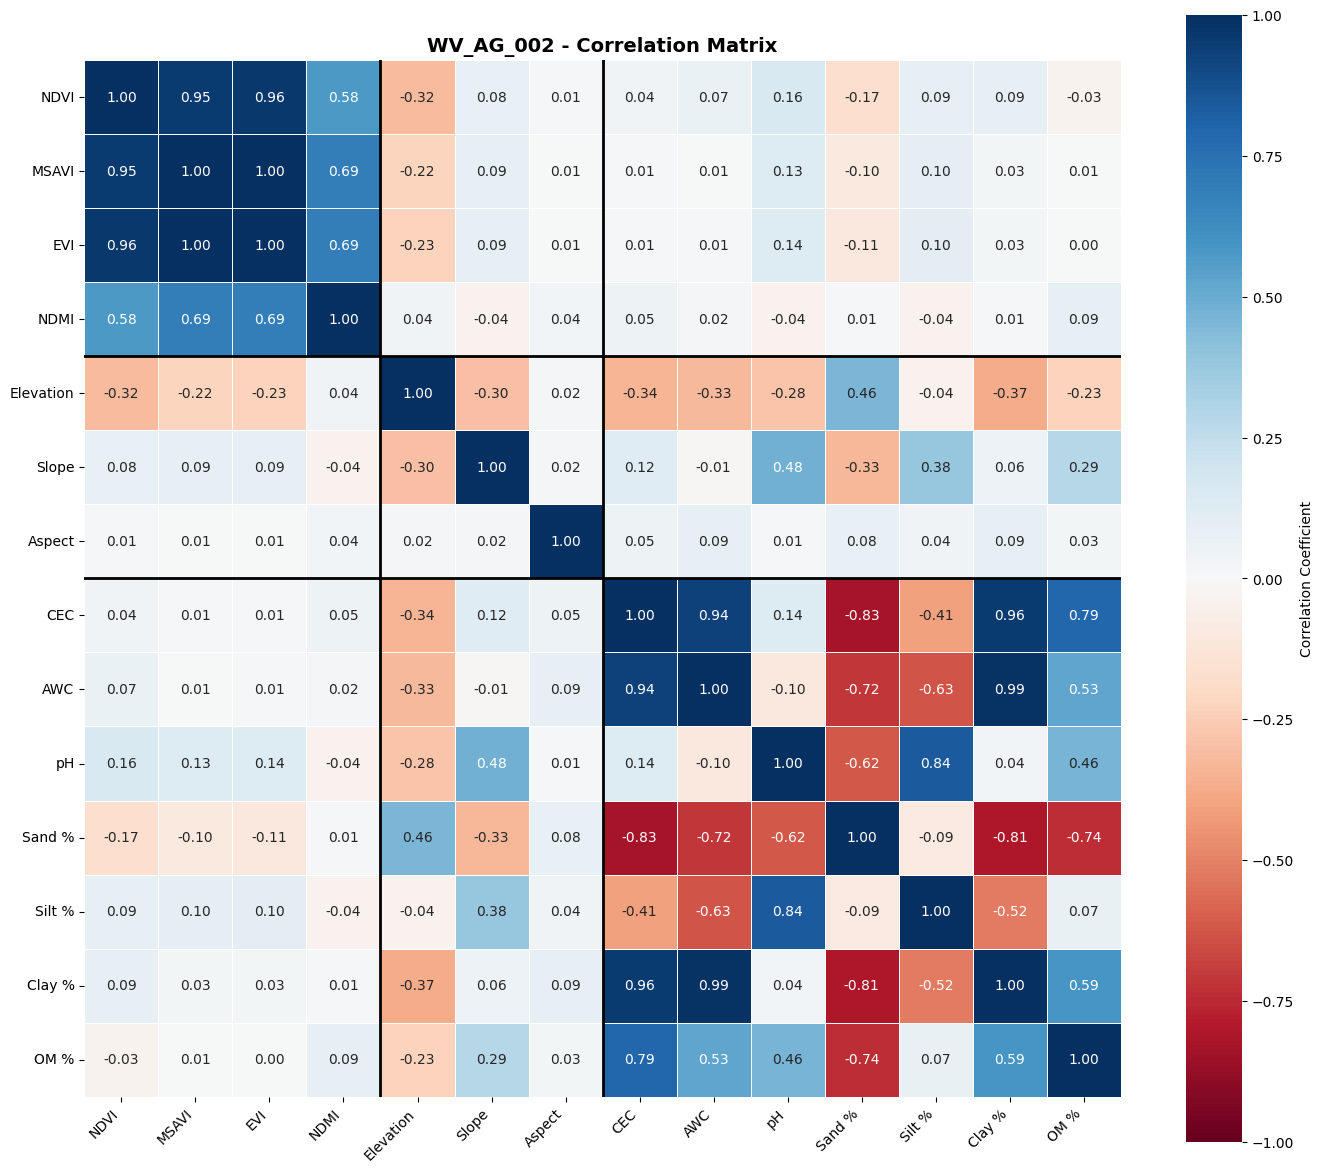

In [105]:
# Correlation Matrix
import seaborn as sns
from scipy import stats
from rasterio import mask

# Define metrics grouped by category (Satellite, Terrain, Soil)
metric_order = [
    # Satellite (4)
    ('satellite', 'ndvi', 'NDVI'),
    ('satellite', 'msavi', 'MSAVI'),
    ('satellite', 'evi', 'EVI'),
    ('satellite', 'ndmi', 'NDMI'),
    # Terrain (3)
    ('terrain', 'elevation', 'Elevation'),
    ('terrain', 'slope', 'Slope'),
    ('terrain', 'aspect', 'Aspect'),
    # Soil (7)
    ('soil', 'cec', 'CEC'),
    ('soil', 'awc', 'AWC'),
    ('soil', 'ph', 'pH'),
    ('soil', 'sand_pct', 'Sand %'),
    ('soil', 'silt_pct', 'Silt %'),
    ('soil', 'clay_pct', 'Clay %'),
    ('soil', 'om_pct', 'OM %'),
]

def load_metric_polygon(field_id, data_type, metric):
    """Load a single metric's pixels within the polygon."""
    polygon = get_field_polygon(field_id)
    
    if data_type == 'satellite':
        filepath = os.path.join(SATELLITE_DIR, f'{field_id}_{metric}.tif')
    elif data_type == 'terrain':
        filepath = os.path.join(TERRAIN_DIR, f'{field_id}_{metric}.tif')
    else:  # soil
        filepath = os.path.join(SOIL_DIR, f'{field_id}_soil_{metric}.tif')
    
    with rasterio.open(filepath) as src:
        out_image, out_transform = mask.mask(src, [polygon], crop=True)
        data = out_image[0]
        nodata = src.nodata
    
    values = data.flatten()
    if nodata is not None and not np.isnan(nodata):
        values = values[values != nodata]
    values = values[~np.isnan(values)]
    
    return values

def circular_correlation(x, y):
    """Calculate circular correlation for aspect values."""
    # Convert to radians
    x_rad = np.deg2rad(x)
    y_rad = np.deg2rad(y)
    
    # Compute circular correlation coefficient
    x_sin = np.sin(x_rad)
    x_cos = np.cos(x_rad)
    y_sin = np.sin(y_rad)
    y_cos = np.cos(y_rad)
    
    # Calculate Pearson correlation between all pairs
    r_xsin_ysin = np.corrcoef(x_sin, y_sin)[0, 1]
    r_xsin_ycos = np.corrcoef(x_sin, y_cos)[0, 1]
    r_xcos_ysin = np.corrcoef(x_cos, y_sin)[0, 1]
    r_xcos_ycos = np.corrcoef(x_cos, y_cos)[0, 1]
    
    # Combine
    r = np.sqrt((r_xsin_ysin + r_xcos_ycos)**2 + (r_xsin_ycos + r_xcos_ysin)**2) / 2
    
    return r

def compute_pvalue_matrix(metrics_data):
    """Compute pairwise p-value matrix for all metrics."""
    n = len(metric_order)
    pval_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                pval_matrix[i, j] = 0.0
            elif i < j:
                continue
            else:
                x_values = metrics_data[i]
                y_values = metrics_data[j]
                
                min_len = min(len(x_values), len(y_values))
                if min_len < 3:
                    pval_matrix[i, j] = np.nan
                    pval_matrix[j, i] = np.nan
                    continue
                
                x = x_values[:min_len]
                y = y_values[:min_len]
                
                _, _, name_i = metric_order[i]
                _, _, name_j = metric_order[j]
                
                if name_i == 'Aspect' or name_j == 'Aspect':
                    _, p = stats.pearsonr(np.sin(np.deg2rad(x)), np.sin(np.deg2rad(y)))
                else:
                    _, p = stats.pearsonr(x, y)
                
                pval_matrix[i, j] = p
                pval_matrix[j, i] = p
    
    return pval_matrix

def compute_correlation_matrix(metrics_data):
    """Compute pairwise correlation matrix for all metrics."""
    n = len(metric_order)
    corr_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                corr_matrix[i, j] = 1.0
            elif i < j:
                # Already computed, skip
                continue
            else:
                x_values = metrics_data[i]
                y_values = metrics_data[j]
                
                # Align lengths
                min_len = min(len(x_values), len(y_values))
                if min_len < 3:
                    corr_matrix[i, j] = np.nan
                    corr_matrix[j, i] = np.nan
                    continue
                
                x = x_values[:min_len]
                y = y_values[:min_len]
                
                # Check if either is aspect (circular)
                _, _, name_i = metric_order[i]
                _, _, name_j = metric_order[j]
                
                if name_i == 'Aspect' or name_j == 'Aspect':
                    # Use circular correlation
                    r = circular_correlation(x, y)
                else:
                    # Standard Pearson correlation
                    r, _ = stats.pearsonr(x, y)
                
                corr_matrix[i, j] = r
                corr_matrix[j, i] = r
    
    return corr_matrix

# Load all metrics for the field
print(f"Loading metrics for {FIELD_ID}...")
metrics_data = []
for data_type, metric, name in metric_order:
    values = load_metric_polygon(FIELD_ID, data_type, metric)
    metrics_data.append(values)
    print(f"  {name}: {len(values)} pixels")

# Compute correlation matrix
print("\nComputing correlation matrix...")
corr_matrix = compute_correlation_matrix(metrics_data)
metric_names = [name for _, _, name in metric_order]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu',
    vmin=-1,
    vmax=1,
    center=0,
    xticklabels=metric_names,
    yticklabels=metric_names,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=ax
)

ax.set_title(f'{FIELD_ID} - Correlation Matrix', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Add category separators
ax.axhline(y=4, color='black', linewidth=2)
ax.axhline(y=7, color='black', linewidth=2)
ax.axvline(x=4, color='black', linewidth=2)
ax.axvline(x=7, color='black', linewidth=2)

plt.tight_layout()
plt.show()

## P-value Significance Matrix

Computing p-value matrix...


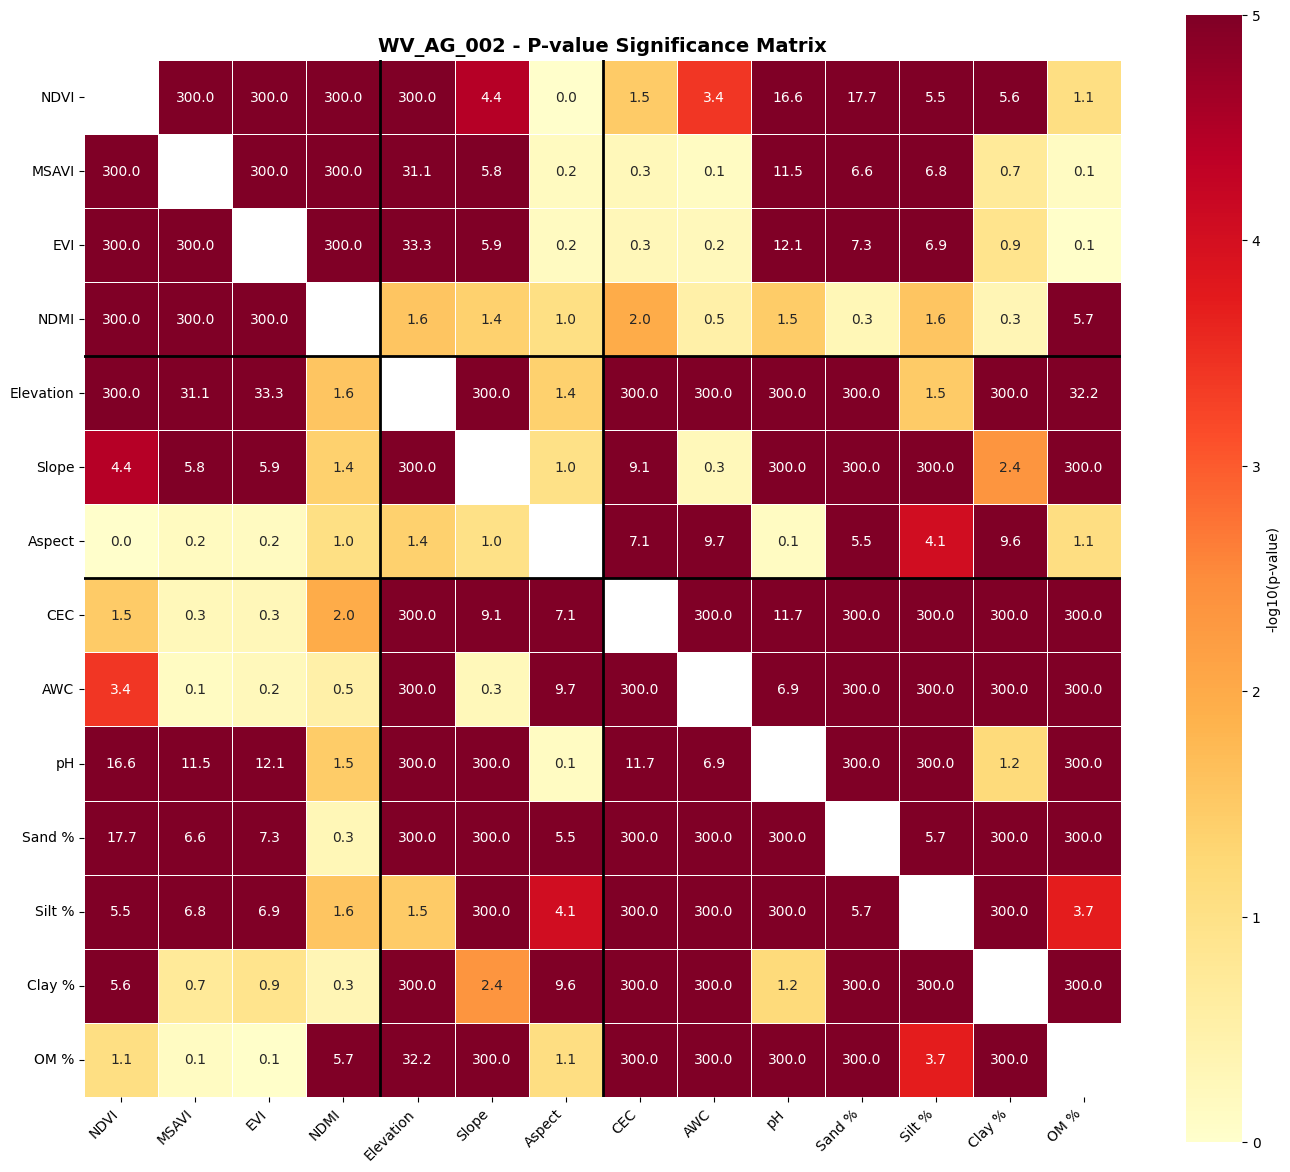


Significance thresholds:
  -log10(0.05) ≈ 1.3  (p < 0.05)
  -log10(0.01) = 2.0  (p < 0.01)
  -log10(0.001) = 3.0 (p < 0.001)


In [103]:
# P-value Significance Matrix
print("Computing p-value matrix...")
pval_matrix = compute_pvalue_matrix(metrics_data)

# Convert to -log10(p-values), handle edge cases
# p=0 -> np.inf, add small value to avoid log(0)
log10_pval = -np.log10(pval_matrix + 1e-300)
np.fill_diagonal(log10_pval, np.inf)  # Diagonal is perfectly significant

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    log10_pval,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    vmin=0,
    vmax=5,
    xticklabels=metric_names,
    yticklabels=metric_names,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': '-log10(p-value)'},
    ax=ax
)

ax.set_title(f'{FIELD_ID} - P-value Significance Matrix', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Add category separators
ax.axhline(y=4, color='black', linewidth=2)
ax.axhline(y=7, color='black', linewidth=2)
ax.axvline(x=4, color='black', linewidth=2)
ax.axvline(x=7, color='black', linewidth=2)

plt.tight_layout()
plt.show()

# Print significance thresholds
print("\nSignificance thresholds:")
print("  -log10(0.05) ≈ 1.3  (p < 0.05)")
print("  -log10(0.01) = 2.0  (p < 0.01)")
print("  -log10(0.001) = 3.0 (p < 0.001)")

## How This Was Made

This notebook analyzes multi-source geospatial data for 50 agricultural fields in Oregon's Willamette Valley. The data was generated using a series of Python scripts that query various federal APIs and process the results.

### Data Generation Pipeline

**1. Field Boundaries**
- Source: `fields_oregon_willamette_ag_2025.geojson`
- 50 fields (WV_AG_001 to WV_AG_050) in Oregon's Willamette Valley
- Coordinate reference: EPSG:4326 (WGS84)

**2. Satellite Indices** (`generate_satellite_rasters.py`)
- **Source API**: Copernicus Data Space (Sentinel-2 L2A)
- **Search Endpoint**: STAC API (`https://stac.dataspace.copernicus.eu/v1/search`)
- **Processing Endpoint**: Process API (`https://sh.dataspace.copernicus.eu/api/v1/process`)
- **Imagery Date**: March 7, 2026
- **Cloud Cover Threshold**: ≤30%
- **Search Window**: ±30 days (expanded to ±60 days if no scenes found)
- **Sentinel-2 Bands Used**: B04 (Red, 665nm), B08 (NIR, 842nm), B11 (SWIR, 1610nm)
- **Indices Computed**:
  - **NDVI** = (B08 - B04) / (B08 + B04) — Normalized Difference Vegetation Index
  - **MSAVI** = (2·B08 + 1 - √((2·B08 + 1)² - 8·(B08 - B04))) / 2 — Modified SAVI
  - **EVI** = 2.5·(B08 - B04) / (B08 + 2.4·B04 + 1) — Enhanced Vegetation Index
  - **NDMI** = (B08 - B11) / (B08 + B11) — Normalized Difference Moisture Index

**3. Terrain Data** (`batch_terrain.py` → `lat_lon_polygon_to_dem_slope_aspect.py`)
- **Source API**: USGS 3DEP Elevation API
- **Endpoint**: `https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/exportImage`
- **Target Resolution**: 5m (falls back to 10m, then 30m if unavailable)
- **Interpolation**: Bilinear
- **Output Rasters**:
  - `{field_id}_elevation.tif` — Float32, meters above sea level
  - `{field_id}_slope.tif` — Float32, degrees (0-90)
  - `{field_id}_aspect.tif` — Float32, degrees (0-360, 0=North, 90=East)
- **Slope/Aspect Calculation**: `np.gradient()` on elevation with pixel dimensions in meters

**4. Soil Data** (Three-stage pipeline)
- **Stage 1** (`batch_soil.py` → `lat_lon_polygon_to_ssurgo_soil.py`)
  - **Source API**: USDA NRCS Soil Data Access
  - **Endpoint**: `https://sdmdataaccess.sc.egov.usda.gov/Tabular/post.rest`
  - **Query Method**: SQL queries via REST API
  - **Data Retrieved**: SSURGO map units (mukey), polygon geometries, and horizon-level properties
  - **Properties Queried**: CEC (cmol₍c₎/kg), AWC (cm/cm), pH (1:1 H₂O), sand/silt/clay %, OM %
  - **Output**: `{field_id}_soil.tif` (integer map unit labels), `{field_id}_soil_labels.json` (definitions)

- **Stage 2** (`generate_soil_property_rasters.py`)
  - Converts integer soil map unit labels to floating-point property values
  - Uses dominant component and first horizon (hzdept_r) for each map unit
  - **Properties Extracted**: CEC7_r, AWC_r, ph1to1h2o_r, sandtotal_r, silttotal_r, claytotal_r, om_r

- **Stage 3** (`resample_rasters.py`)
  - **Source Resolution**: 5m (native SSURGO varies by map unit polygon size)
  - **Target Resolution**: 10m
  - **Resampling Method**: Bilinear for continuous properties

### Processing Parameters

| Parameter | Value |
|-----------|-------|
| Padding | 15% of field bounding box (applied to all data types) |
| Target Resolution | 10m (all data types) |
| Coordinate System | EPSG:4326 (WGS84) |
| Output Format | Float32 GeoTIFF |
| NoData Value | NaN (soil properties), -9999 (terrain/aspect) |
| Cloud Threshold | ≤30% (satellite) |
| Search Window | ±30 days (satellite scene selection) |

### File Naming Convention

- **Satellite**: `{field_id}_{index}.tif` (e.g., `WV_AG_006_ndvi.tif`)
- **Terrain**: `{field_id}_{metric}.tif` (e.g., `WV_AG_006_elevation.tif`)
- **Soil**: `{field_id}_soil_{property}.tif` (e.g., `WV_AG_006_soil_cec.tif`)

### Data Directory Structure

| Directory | Contents | Files |
|-----------|---------|-------|
| `data/satellite/` | NDVI, MSAVI, EVI, NDMI | 4 indices × 50 fields = 200 files |
| `data/terrain/` | Elevation, Slope, Aspect | 3 metrics × 50 fields = 150 files |
| `data/soil_properties_resampled/` | CEC, AWC, pH, Sand%, Silt%, Clay%, OM% | 7 properties × 50 fields = 350 files |

### Key Scripts Used

| Script | Purpose |
|--------|---------|
| `generate_satellite_rasters.py` | Query Copernicus API, compute vegetation indices |
| `batch_terrain.py` | Orchestrate terrain generation for all fields |
| `lat_lon_polygon_to_dem_slope_aspect.py` | Fetch USGS DEM, compute slope/aspect |
| `batch_soil.py` | Orchestrate soil data retrieval for all fields |
| `lat_lon_polygon_to_ssurgo_soil.py` | Query NRCS API, rasterize soil polygons |
| `generate_soil_property_rasters.py` | Convert soil labels to property values |
| `resample_rasters.py` | Resample all data to 10m resolution |


## Data Sources

### Primary Data Providers

| Source | Data Type | API/URL | License |
|--------|-----------|---------|----------|
| ESA Copernicus | Sentinel-2 L2A Satellite Imagery | https://dataspace.copernicus.eu | Free (registration required) |
| USGS NED | Elevation, Slope, Aspect | https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ | Public Domain |
| USDA NRCS | SSURGO Soil Data | https://sdmdataaccess.sc.egov.usda.gov | Public Domain |

### Dataset Details

**Sentinel-2 Level-2A**
- Collection: Sentinel-2 MSI Level-2A
- Processing Level: Bottom-of-atmosphere reflectance
- Spatial Resolution: 10m (Bands 4, 8, 11)
- Temporal Coverage: March 7, 2026 (single scene per field)
- Cloud Masking: Used Copernicus scene cloud cover metadata

**USGS National Elevation Dataset (NED)**
- Resolution: 1/3 arc-second (~10m in study area)
- Vertical Accuracy: RMSE ≤ 1.6m
- Coverage: Full conterminous US
- Last Updated: 2021

**USDA SSURGO (Soil Survey Geographic Database)**
- Map Unit Symbols: Dominant component per polygon
- Horizon Data: First horizon (0-? cm) for each component
- Spatial Scale: 1:24,000
- Publication Date: 2024

### Field Data

- **Location**: Oregon Willamette Valley
- **Fields**: 50 agricultural fields
- **Geometry Source**:USDA NASS Crop Sequence Boundaries (2025)
- **Field IDs**: WV_AG_001 through WV_AG_050

### Citation

When using this data, please cite:

1. **Satellite Imagery**: European Space Agency (2026). Sentinel-2 Level-2A. Copernicus Data Space Ecosystem. https://dataspace.copernicus.eu

2. **Elevation Data**: USGS National Elevation Dataset. U.S. Geological Survey. https://nationalmap.gov/elevation.html

3. **Soil Data**: USDA Natural Resources Conservation Service. Soil Survey Geographic (SSURGO) Database. https://sdmdataaccess.nrcs.usda.gov

4. **Crop Boundaries**: USDA National Agricultural Statistics Service (2025). Cropland Data Layer. https://nassgeodata.gmu.edu
